In [1]:
# How will we do regression for multiple features?

In [12]:
import numpy as np
x1 =np.array([1,2,3,4,5,6,7,8,9,10])
x2 = np.array([40,45,50,55,60,65,70,75,80,85])
y = np.array([35,40,45,50,55,58,65,72,84,92])

x1.shape,x2.shape,y.shape

((10,), (10,), (10,))

In [13]:
X = np.column_stack([x1,x2])
X.shape

(10, 2)

In [14]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [15]:
model = LinearRegression()
model.fit(X,y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
m= model.coef_
b = model.intercept_
m,b

(array([0.23403263, 1.17016317]), np.float64(-14.822377622377608))

In [17]:
model.predict(X),y

(array([32.21818182, 38.3030303 , 44.38787879, 50.47272727, 56.55757576,
        62.64242424, 68.72727273, 74.81212121, 80.8969697 , 86.98181818]),
 array([35, 40, 45, 50, 55, 58, 65, 72, 84, 92]))

In [29]:
x1_grid , x2_grid = np.meshgrid(x1,x2)
y_grid = model.predict(np.column_stack([x1_grid.ravel(),x2_grid.ravel()]))
y_grid = y_grid.reshape(x1_grid.shape)
y_grid

array([[32.21818182, 32.45221445, 32.68624709, 32.92027972, 33.15431235,
        33.38834499, 33.62237762, 33.85641026, 34.09044289, 34.32447552],
       [38.06899767, 38.3030303 , 38.53706294, 38.77109557, 39.00512821,
        39.23916084, 39.47319347, 39.70722611, 39.94125874, 40.17529138],
       [43.91981352, 44.15384615, 44.38787879, 44.62191142, 44.85594406,
        45.08997669, 45.32400932, 45.55804196, 45.79207459, 46.02610723],
       [49.77062937, 50.004662  , 50.23869464, 50.47272727, 50.70675991,
        50.94079254, 51.17482517, 51.40885781, 51.64289044, 51.87692308],
       [55.62144522, 55.85547786, 56.08951049, 56.32354312, 56.55757576,
        56.79160839, 57.02564103, 57.25967366, 57.49370629, 57.72773893],
       [61.47226107, 61.70629371, 61.94032634, 62.17435897, 62.40839161,
        62.64242424, 62.87645688, 63.11048951, 63.34452214, 63.57855478],
       [67.32307692, 67.55710956, 67.79114219, 68.02517483, 68.25920746,
        68.49324009, 68.72727273, 68.96130536

In [30]:
x1_grid.shape,x2_grid.shape,y_grid.shape

((10, 10), (10, 10), (10, 10))

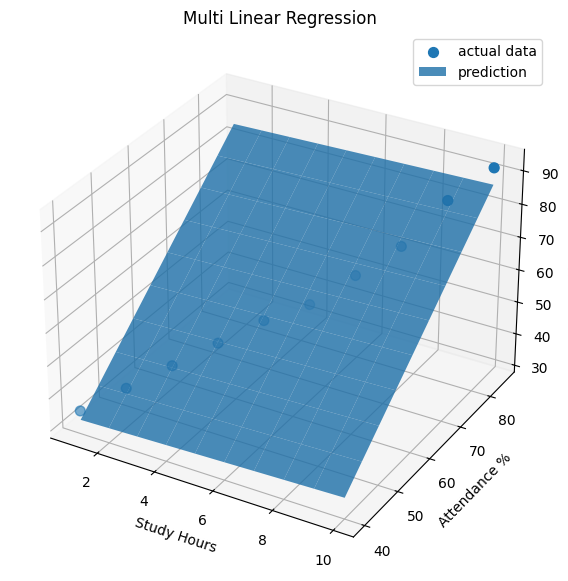

In [49]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111,projection="3d")
ax.scatter(x1,x2,y,label ="actual data",s=50)
ax.plot_surface(x1_grid,x2_grid,y_grid,alpha=0.8, label="prediction")
ax.set_xlabel("Study Hours")
ax.set_ylabel("Attendance %")
ax.set_zlabel("Marks")
ax.set_title("Multi Linear Regression")
ax.legend()
plt.show()

In [50]:
import plotly.graph_objects as go
fig =go.Figure()

In [59]:
fig.add_trace(
    go.Scatter3d(
        x=x1, y=x2, z=y, mode="markers", marker=dict(size=6), name="actual Data"
    )
)
fig.add_trace(
    go.Surface(x=x1_grid, y=x2_grid, z=y_grid, opacity=0.6, name="Regression Plane")
)
fig.update_layout(
    title="Multiple Linear Regression",
    scene=dict(
        xaxis_title="Study Hours", yaxis_title="Attendance %", zaxis_title="Exam Score"
    ),
)
fig.show()